# S&P 500 Equity+Options: Strategy Assessment

This notebook is the last of the sequence and it creates nothing. It traces one
primary-label carrier from the equal-weight baseline through position sizing,
fixed risk controls and cost sensitivity - the order those stages run in - and
then reads the holdout result that `18_holdout_predictions` and
`19_holdout_backtest` produced for the configuration that funnel selected.

**Learning objectives**

1. Reconstruct the current carrier from configured, full-coverage registry
   rows rather than from the global maximum Sharpe.
2. Read stage progression, cost survival, paired risk uncertainty, and
   selection adjustment as distinct diagnostics.
3. Enforce one holdout use when methodology repairs change the validation
   carrier after the holdout has already been observed.
4. Produce a publication assessment that distinguishes validation evidence
   from unresolved out-of-sample efficacy.

**Book reference:** Chapter 20, Sections 20.1, 20.6, and 20.7.

**Prerequisites:** notebooks `14_backtest` through `17_costs` and
their corrected v3.1 registry rows. This notebook is read-only: it trains no
model, runs no backtest, and writes no registry result.

**Population scope:** The case study uses a current-constituent roster rather
than point-in-time S&P 500 membership. Historical results describe this
retrospective roster and do not establish performance for the index's
membership process or a prospective S&P 500 population.

In [1]:
"""S&P 500 Equity+Options: corrected strategy assessment."""

import json
import sqlite3
import warnings

import matplotlib.pyplot as plt
import polars as pl

warnings.filterwarnings("ignore")

Shared helpers reconstruct the configured funnel and its uncertainty from
registry artifacts without launching another training or evaluation run.

In [2]:
from case_studies.research import CandidateSet, Study, open_selection_field
from case_studies.research.holdout import build_holdout_training_spec
from case_studies.utils.backtest_loaders import get_backtest_config
from case_studies.utils.backtest_presets import (
    clone_backtest_spec,
    set_backtest_costs_bps,
    set_backtest_costs_per_share,
    strategy_view,
)
from case_studies.utils.cv_window import canonical_window
from case_studies.utils.notebook_contracts import prediction_members_in_force
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    load_backtest_fold_metrics,
    read_predictions,
    resolve_best_backtest_runs,
)
from case_studies.utils.registry.specs import training_hash_from_spec
from case_studies.utils.strategy_analysis import resolve_solvent_carrier
from case_studies.utils.sweep_config import (
    get_cost_grid_bps,
    get_cost_grid_half_spread_usd,
    get_per_share_commission,
    get_position_risk_controls,
)
from case_studies.utils.uncertainty import (
    compute_cohort_metrics,
    compute_paired_uncertainty,
    load_daily_returns_with_timestamp,
    periods_per_year_from_setup,
)
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title

In [3]:
CASE_STUDY = "sp500_equity_option_analytics"
SEED = 42

In [4]:
CASE_DIR = get_case_study_dir(CASE_STUDY)
REGISTRY_DB = CASE_DIR / "run_log" / "registry.db"
bt_config = get_backtest_config(CASE_STUDY)
# The label this stage runs under is a property of what the selection chose, so it is resolved
# below rather than here. `labels.primary` was the winner's label only by coincidence: the field
# spans every declared label, and the stages after the selection - price windows, schedule
# thinning, the return contract - have to be keyed to the label that won.
REQUESTED_LABEL = ""
PERIODS_PER_YEAR = periods_per_year_from_setup(CASE_STUDY)
CONFIGURED_COST_BPS = bt_config.commission_bps + bt_config.slippage_bps
set_global_seeds(SEED)

print(f"Case study: {CASE_STUDY}; mode: registry read-only")

Case study: sp500_equity_option_analytics; mode: registry read-only


## 1. Reconstruct the corrected carrier

The funnel advances the full-coverage baseline configurations `setup.yaml`
declares for the allocation stage on the primary label, filters allocation rows
to the allocators it declares, and filters risk rows to the predeclared
controls. Historical conformal rows, alternate labels, and full-validation
MAE-calibrated rules cannot enter.

Coverage is measured against the canonical validation window
(``coverage_window="canonical"``), not the raw stored day count: this
registry's sweep predates the outcome-horizon boundary, and some checkpoints
carry a few decision dates from before it that inflate their raw count without
covering any more of the modeling window.

**The advancing configurations are drawn from the populations in force, not from every generation
the registry holds.** A population is immutable and refitting one publishes a snapshot that
supersedes the old, with both left readable; nothing in the read path filters on that
(`case_studies/utils/registry/queries.py` contains no occurrence of `supersed`). Unfiltered, a
retired generation competes for a slot against its own replacement, and the funnel below reports
fewer distinct strategies than it appears to. The set is passed into the query rather than
applied to its output because it also scopes the full-coverage bar the ranking is measured
against.

In [5]:
# `Study.at` is the read-only form: one root, no activation. These notebooks only read the
# populations - their backtests reach the registry by their own paths - and every other way in
# ends in `activate()`, which rewrites `ML4T_OUTPUT_DIR` process-wide. `open_study` with the
# canonical tier routes to `Study.regenerate`, which refuses unless `features`, `labels` and
# `run_log` are symlinks: true in a maintainer worktree, false in every clean clone and CI run.
# `CASE_DIR` is already the directory this notebook resolved, including under a preview, so
# asking it directly answers for the registry the rest of the notebook reads.
_study = Study.at(CASE_DIR, case_study=CASE_STUDY, entry_point="20_strategy_analysis")
_members, _population_notes = prediction_members_in_force(_study)
for _note in _population_notes:
    print(_note)
CURRENT_MEMBERS = _members
if CURRENT_MEMBERS is not None:
    print(f"{len(CURRENT_MEMBERS):,} prediction sets in the populations in force")

947 prediction sets in the populations in force


In [6]:
CANDIDATE_SET_NAME = f"{CASE_STUDY}:holdout-candidates"
# The frozen set where it exists, and the same construction applied live where it does not.
# 16_risk_management writes it by opening the study, which canonical regeneration refuses
# wherever the generated directories are not symlinks - a reader's clean clone and the test
# fixtures both - so the set is in the published run log and absent everywhere else. Reading it
# is the stronger path: it is immutable, so it cannot follow an upstream change. Re-deriving is
# the same rule applied live, and cannot notice that something moved. Which one ran is printed.
#
# Both paths go through `open_selection_field`, which is also what 16 freezes with. They used to
# be separate copies and they disagreed: the freeze spanned every declared label and this
# fallback spanned one, so which configuration a reader selected depended on whether their
# registry held a `candidate_sets` table.
FIELD = open_selection_field(
    _study,
    case_study=CASE_STUDY,
    name=CANDIDATE_SET_NAME,
    prediction_hashes=CURRENT_MEMBERS,
    resolve_best_backtest_runs=resolve_best_backtest_runs,
)
CANDIDATES = FIELD.candidate_set
FIELD_HASHES = list(FIELD.members)
# The field says which backtests may be chosen from; the resolver says which one is chosen.
# `SelectionField` answers both through `best_validation_sharpe`, which ranks the stored
# Sharpe column with a hash tie-break and nothing else - no re-ranking on the timestamps the
# candidates share, no solvency refusal, no label or universe restriction. On this registry
# the two name the same backtest and report different numbers for it: 2.6087 stored against
# 2.6329 over the sessions every candidate prices, because the field holds a conformal
# allocator that sits out its warm-up and books it as returns of exactly zero. The resolver
# is what `18_holdout_predictions` and `19_holdout_backtest` run, so it is what this page
# has to report.
CARRIER = resolve_solvent_carrier(CASE_STUDY, admitted=frozenset(FIELD_HASHES))
SELECTED = _study.results.open(CARRIER["val_backtest_hash"])
FIELD_NAME = f"frozen candidate set {CANDIDATES.hash}" if CANDIDATES is not None else "live ranking"
SELECTION_SOURCE = FIELD.source

# The label the stages after the selection run under is the winner's, not the case study's
# primary. An injected LABEL is a request to run a different one, and it has to agree with what
# was selected or the analysis would be keyed to a contract the selection does not name.
LABEL = CARRIER["label"]
if REQUESTED_LABEL and REQUESTED_LABEL != LABEL:
    raise RuntimeError(
        f"LABEL={REQUESTED_LABEL!r} was requested but the selection carried forward is "
        f"{SELECTED.hash} on {LABEL!r}. Running the analysis under another "
        "label's contract would report a different strategy from the one selected."
    )
print(f"Label carried by the selection: {LABEL}")
print(f"Selection read from the {SELECTION_SOURCE}")

_why = SELECTED.completeness()
if _why is not None:
    raise RuntimeError(
        f"the selected validation backtest {SELECTED.hash} is incomplete: {_why}. "
        f"It was chosen from the {SELECTION_SOURCE}."
    )
if SELECTED.execution_tier != "canonical":
    raise RuntimeError(f"the selected validation backtest {SELECTED.hash} is not canonical")

# Every later comparison in this notebook is drawn from the frozen set rather than re-queried,
# so the field the carrier is judged against is the field it was selected from. Sharpe lives in
# `backtest_metrics` rather than on the run row, so it is joined here once.
# `members` is a tuple of hashes, not of results, so each is opened once here.
_member_hashes = list(FIELD_HASHES)
with sqlite3.connect(REGISTRY_DB) as db:
    _member_metrics = dict(
        db.execute(
            "SELECT backtest_hash, sharpe FROM backtest_metrics WHERE backtest_hash IN "
            f"({','.join('?' for _ in _member_hashes)})",
            _member_hashes,
        ).fetchall()
    )
_candidate_rows = []
for _member_hash in _member_hashes:
    _member = _study.results.open(_member_hash)
    _spec = _member.spec()
    _view = strategy_view(_spec)
    _candidate_rows.append(
        {
            "backtest_hash": _member.hash,
            "prediction_hash": _member.registry_record()["prediction_hash"],
            "spec_json": json.dumps(_spec),
            "sharpe": _member_metrics.get(_member.hash),
            "allocator": (_view.get("allocation") or {}).get("method", "equal_weight"),
            "top_k": (_view.get("signal") or {}).get("top_k"),
            "risk": (_view.get("risk") or {}).get("name"),
        }
    )
candidate_frame = pl.DataFrame(_candidate_rows)
if candidate_frame.filter(pl.col("sharpe").is_null()).height:
    raise RuntimeError("a frozen candidate carries no registered Sharpe")

strategy_carrier = candidate_frame.filter(pl.col("backtest_hash") == SELECTED.hash).row(
    0, named=True
)
# The equal-weight rows inside the frozen set, which is where the carrier's starting point comes
# from. Drawing it from the set rather than re-querying keeps baseline and lineage under one
# eligibility rule - the one the set was frozen under.
baseline_pool = candidate_frame.filter(
    (pl.col("allocator") == "equal_weight") & pl.col("risk").is_null()
)
# Two numbers for one run, and they are not interchangeable. `val_sharpe` is what the
# selection was made on: the field holds a conformal allocator that sits out its warm-up and
# books it as returns of exactly zero, so every candidate is re-ranked over the sessions they
# all price. `sharpe` is what `backtest_metrics` stores, computed over this run's own span.
# The stored column is what the within-frame comparisons below are drawn from - a difference
# between two rows of it is meaningful, and a difference between it and the selection metric
# is not - so both are printed rather than one silently standing for the other.
print(
    f"{FIELD_NAME}: {len(FIELD_HASHES)} members "
    f"({baseline_pool.height} equal-weight baselines), selected {SELECTED.hash} "
    f"at validation Sharpe {CARRIER['val_sharpe']:.3f} over the sessions every candidate "
    f"prices ({strategy_carrier['sharpe']:.3f} as registered over its own span)"
)

Label carried by the selection: fwd_ret_risk_adj_5d
Selection read from the frozen candidate set 7fd2e57b3796 (3811 members)


frozen candidate set 7fd2e57b3796: 3811 members (2841 equal-weight baselines), selected c8212eda3bca at validation Sharpe 2.633 over the sessions every candidate prices (2.609 as registered over its own span)


The canonical fold boundary incorporates the five-session outcome horizon: a
decision made on the last validation day has its five-session return observable
before the holdout opens. The registry was swept before that boundary was
adopted, so its last validation fold runs to the holdout start and carries a
horizon's worth of decisions whose outcome is only observable inside the
holdout. The printout below reports how many decisions and return days that
comes to. Everything after it reads the canonical span, which is what keeps the
holdout out of selection.

In [7]:
validation_window = canonical_window(CASE_STUDY, LABEL, split="validation")
if validation_window is None:
    raise RuntimeError(f"No canonical validation window derivable for {LABEL}")


def to_canonical_window(frame: pl.DataFrame | None) -> pl.DataFrame | None:
    """Cut a timestamped artifact to the canonical validation window."""
    if frame is None:
        return None
    return frame.filter(
        pl.col("timestamp").cast(pl.Date).is_between(validation_window[0], validation_window[1])
    )


def canonical_daily_returns(backtest_hash: str) -> pl.DataFrame | None:
    """Registered daily returns for one backtest, cut to the canonical window."""
    return to_canonical_window(load_daily_returns_with_timestamp(CASE_STUDY, backtest_hash))


registered_predictions = read_predictions(CASE_STUDY, strategy_carrier["prediction_hash"])
carrier_predictions = to_canonical_window(registered_predictions)
if carrier_predictions.is_empty():
    raise RuntimeError("The strategy carrier has no decisions in the canonical validation window")
latest_decision = carrier_predictions["timestamp"].max()
latest_decision_date = (
    latest_decision.date() if hasattr(latest_decision, "date") else latest_decision
)
registered_returns = load_daily_returns_with_timestamp(
    CASE_STUDY, strategy_carrier["backtest_hash"]
)
if registered_returns is None:
    raise RuntimeError("The strategy carrier has no registered daily-return artifact")
carrier_returns = to_canonical_window(registered_returns)
# Measured on the UNSEALED frame. Sealing first makes the comparison one-sided: the
# min/max of an already-trimmed frame can only fall short of the window, never past
# it, so a registered artifact that overruns the seal reads as a clean match.
registered_dates = registered_returns["timestamp"].cast(pl.Date)
if registered_dates.is_empty():
    raise RuntimeError("The strategy carrier's registered daily-return artifact is empty")
registered_window = (registered_dates.min(), registered_dates.max())
if registered_window[0] > validation_window[0] or registered_window[1] < validation_window[1]:
    raise RuntimeError(
        "The registered strategy carrier does not cover the canonical validation window: "
        f"registered={registered_window}, canonical={validation_window}"
    )
dropped = len(registered_predictions) - len(carrier_predictions)
dropped_returns = len(registered_returns) - len(carrier_returns)
print(
    f"Canonical validation window: {validation_window[0]} to {validation_window[1]}; "
    f"carrier latest decision: {latest_decision_date}; "
    f"decisions dropped past the window: {dropped}; "
    f"return days dropped past the window: {dropped_returns}"
)

Canonical validation window: 2019-01-07 to 2020-12-23; carrier latest decision: 2020-12-23; decisions dropped past the window: 0; return days dropped past the window: 0


In [8]:
fixed_controls = get_position_risk_controls(CASE_STUDY)
risk_plans = []
# The carrier is drawn from a pool that now includes the risk overlays, so it may already carry
# one. Every comparison below is against the strategy the overlay was laid over, not against the
# overlay itself: on an overlaid carrier, reusing it as its own baseline reports a paired
# improvement of exactly zero and silently drops the allocation-only figure the reader is shown.
#
# The parent is found in the frozen set rather than reconstructed by stripping the risk block.
# Stripping does not reproduce it - the two rows also differ in the `chapter` tag that records
# which stage registered them, and that tag is inside the backtest identity - so a reconstructed
# hash names a row that does not exist. What identifies the parent is what it is: the member of
# the same frozen set, on the same predictions, with the same allocator and concentration, and
# no overlay.
CARRIER_SPEC = json.loads(strategy_carrier["spec_json"])


def _un_overlaid_parents(frame: pl.DataFrame) -> pl.DataFrame:
    """Rows in ``frame`` that are this carrier's strategy without the overlay."""
    return frame.filter(
        (pl.col("prediction_hash") == strategy_carrier["prediction_hash"])
        & (pl.col("allocator") == strategy_carrier["allocator"])
        & (pl.col("top_k") == strategy_carrier["top_k"])
        & pl.col("risk").is_null()
    )


# The field first, because a parent that competed is the right comparison. But the parent is a
# fact about the carrier rather than about the field - 16_risk_management laid this overlay over
# it - so where the field does not carry it, the registry is asked directly. The two differ
# whenever the field is narrower than the registry: a reduced sweep registers the overlay and
# leaves its un-overlaid sibling outside the eligible set, and requiring field membership would
# refuse to score an overlay whose baseline exists and is complete.
no_overlay_rows = _un_overlaid_parents(candidate_frame)
PARENT_SOURCE = "the frozen field"
if no_overlay_rows.height != 1:
    with sqlite3.connect(REGISTRY_DB) as db:
        _sibling_rows = db.execute(
            """
            SELECT b.backtest_hash, b.prediction_hash, b.spec_json, m.sharpe
            FROM backtest_runs b JOIN backtest_metrics m USING(backtest_hash)
            WHERE b.prediction_hash = ? AND m.sharpe IS NOT NULL
            """,
            (strategy_carrier["prediction_hash"],),
        ).fetchall()
    _siblings = pl.DataFrame(
        [
            {
                "backtest_hash": h,
                "prediction_hash": ph,
                "spec_json": sj,
                "sharpe": sharpe,
                "allocator": (strategy_view(json.loads(sj)).get("allocation") or {}).get(
                    "method", "equal_weight"
                ),
                "top_k": (strategy_view(json.loads(sj)).get("signal") or {}).get("top_k"),
                "risk": (strategy_view(json.loads(sj)).get("risk") or {}).get("name"),
            }
            for h, ph, sj, sharpe in _sibling_rows
        ]
    )
    no_overlay_rows = _un_overlaid_parents(_siblings) if _siblings.height else _siblings
    PARENT_SOURCE = "the registry, outside the eligible field"
if no_overlay_rows.height != 1:
    raise RuntimeError(
        f"the carrier {strategy_carrier['backtest_hash']} has {no_overlay_rows.height} "
        "un-overlaid parents, not one, in the frozen field or in the registry, so its overlay "
        "cannot be scored against the strategy it was laid over"
    )
NO_OVERLAY = no_overlay_rows.row(0, named=True)
NO_OVERLAY_HASH = NO_OVERLAY["backtest_hash"]
if strategy_carrier["risk"] is None and strategy_carrier["backtest_hash"] != NO_OVERLAY_HASH:
    raise RuntimeError(
        "the carrier declares no overlay, so it must be its own un-overlaid parent; got "
        f"{NO_OVERLAY_HASH} against {strategy_carrier['backtest_hash']}"
    )
print(
    f"Un-overlaid parent {NO_OVERLAY_HASH} from {PARENT_SOURCE} "
    f"at validation Sharpe {NO_OVERLAY['sharpe']:.3f}"
    + (
        f"; the carrier adds {strategy_carrier['risk']} for "
        f"{strategy_carrier['sharpe'] - NO_OVERLAY['sharpe']:+.3f}"
        if strategy_carrier["risk"]
        else " (the carrier itself - no overlay was selected)"
    )
)

# Two bases, because the two surfaces were registered against two different strategies and this
# notebook reproduces their identities rather than recomputing them.
#
# `risk_base` is the un-overlaid parent: `16_risk_management` laid each control over that, so a
# variant differs from it in the position rule and nothing else. `cost_base` is the carrier
# itself: `17_costs` stresses whatever survived the risk stage, overlay included. Planning both
# from one spec reproduces neither set of hashes.
risk_base = json.loads(NO_OVERLAY["spec_json"])
cost_base = CARRIER_SPEC
base_spec = risk_base
execution = base_spec["backtest_config"]["execution"]
metadata = base_spec["backtest_config"]["metadata"]
stops = base_spec["backtest_config"]["stops"]
# The cadence is taken from the selected label rather than pinned. What this check is about is
# same-bar information use, and that is decided by the execution mode, the fill timing and the
# stop lag - how often the strategy decides is a separate declaration. Pinning the weekly value
# was correct while every label traded the same grid; now that a label declares its own cadence,
# a correctly selected 10-day winner carries a biweekly one and would abort here.
EXPECTED_CADENCE = bt_config.cadence_for(LABEL)
if (
    execution["execution_mode"] != "next_bar"
    or execution["execution_price"] != "open"
    or metadata["cadence"] != EXPECTED_CADENCE
    or metadata["fill_timing"] != "MONDAY_OPEN"
    or stops["trail_stop_timing"] != "lagged"
):
    raise RuntimeError(
        "Carrier execution or stop timing permits same-bar information use, or its cadence "
        f"{metadata['cadence']!r} is not the {EXPECTED_CADENCE!r} that {LABEL} declares"
    )
for control in fixed_controls:
    spec = clone_backtest_spec(base_spec)
    spec["chapter"] = "ch19"
    rule = {"type": control["type"]}
    if control["type"] == "time_exit":
        rule["bars"] = control["bars"]
    else:
        rule["threshold"] = control["threshold"]
    spec["strategy"]["risk"] = {
        "name": control["name"],
        "position_rules": [rule],
    }
    risk_plans.append(
        {
            "risk_name": control["name"],
            "risk_type": control["type"],
            "backtest_hash": backtest_hash_from_parts(strategy_carrier["prediction_hash"], spec),
        }
    )

Un-overlaid parent 816295114ec6 from the frozen field at validation Sharpe 1.862; the carrier adds stop_loss_3pct for +0.747


Exact planned hashes prevent retired or tuned-on-validation rules from
entering the fixed risk-control surface.

In [9]:
risk_hashes = [plan["backtest_hash"] for plan in risk_plans]
with sqlite3.connect(REGISTRY_DB) as db:
    risk_metrics = pl.read_database(
        f"""
        SELECT b.backtest_hash, b.prediction_hash, b.stage,
               bm.sharpe, bm.sharpe_ci95_lo, bm.sharpe_ci95_hi,
               bm.max_drawdown, bm.cagr, bm.total_return
        FROM backtest_runs b
        JOIN backtest_metrics bm ON b.backtest_hash = bm.backtest_hash
        WHERE b.backtest_hash IN ({",".join("?" for _ in risk_hashes)})
        """,
        connection=db,
        execute_options={"parameters": risk_hashes},
    )
# An empty read comes back with a null-typed join key, which makes the join raise a
# SchemaError before the row-count contract below can report what is actually missing.
risk_metrics = risk_metrics.with_columns(pl.col("backtest_hash").cast(pl.String))
risk_surface = pl.DataFrame(risk_plans).join(risk_metrics, on="backtest_hash", how="inner")
# The guard runs in the direction it was written for: nothing UNPLANNED may enter the surface.
# Requiring the converse - that every declared control has a registered row - asserts something
# only a full sweep can satisfy, and `16_risk_management` registers whichever controls it ran.
# A reduced run truncates that list, so the declared count is a property of the configuration
# and the registered count is a property of the run, and this notebook reports on the run.
_planned = {plan["backtest_hash"] for plan in risk_plans}
with sqlite3.connect(REGISTRY_DB) as db:
    _registered = {
        row[0]
        for row in db.execute(
            "SELECT backtest_hash FROM backtest_runs "
            "WHERE prediction_hash = ? AND stage = 'risk_overlay'",
            (strategy_carrier["prediction_hash"],),
        )
    }
_unplanned = _registered - _planned
if _unplanned:
    raise RuntimeError(
        f"{len(_unplanned)} risk-overlay row(s) on carrier "
        f"{strategy_carrier['prediction_hash']} are not among the declared controls: "
        + ", ".join(sorted(_unplanned)[:5])
        + ". A rule that is not declared in config/setup.yaml cannot enter this surface."
    )
if risk_surface.is_empty():
    raise RuntimeError(
        f"no declared risk control is registered for carrier "
        f"{strategy_carrier['prediction_hash']}, so there is no risk surface to report"
    )
if len(risk_surface) != len(risk_plans):
    print(
        f"{len(risk_surface)} of {len(risk_plans)} declared risk controls are registered for "
        "this carrier; the surface below covers those and says nothing about the rest"
    )
if risk_surface.filter(pl.col("stage") != "risk_overlay").height:
    raise RuntimeError("A corrected risk hash has the wrong registry stage")
no_overlay = {
    "risk_name": "No overlay",
    "risk_type": "none",
    "backtest_hash": NO_OVERLAY_HASH,
    "prediction_hash": strategy_carrier["prediction_hash"],
    "sharpe": NO_OVERLAY["sharpe"],
}
risk_candidates = pl.concat([risk_surface, pl.DataFrame([no_overlay])], how="diagonal_relaxed")
risk_leader = risk_candidates.sort("sharpe", descending=True).row(0, named=True)

The equal-weight starting point comes from the same pool the allocation lineage
was drawn from, so baseline and lineage are judged under one eligibility rule.
Querying it separately would re-apply the raw stored day count and drop this
lineage's prediction, which passes coverage only in the canonical window.

In [10]:
carrier_baselines = baseline_pool.filter(
    pl.col("prediction_hash") == strategy_carrier["prediction_hash"]
)
# The equal-weight starting point is the first step of the funnel, and it is a fact about the
# run rather than about the configuration: 14_backtest registers a baseline per prediction and
# entry scheme it actually swept, and a reduced sweep registers fewer. Where this carrier's
# prediction has none, the funnel starts at the allocation step instead - which is the truth
# about what was measured, and better than refusing to report the rest of the page over a step
# that was never run.
baseline_row = (
    carrier_baselines.sort("sharpe", descending=True).row(0, named=True)
    if not carrier_baselines.is_empty()
    else None
)
if baseline_row is None:
    print(
        f"No equal-weight baseline was registered for carrier prediction "
        f"{strategy_carrier['prediction_hash']}, so the funnel below starts at the allocation "
        "step and no equal-weight comparison is shown"
    )

The visible carrier path retains the equal-weight starting point, the
highest-Sharpe pre-risk strategy, and the risk decision only when it improves
validation.

In [11]:
carrier_rows = (
    [
        {
            "stage": "Equal weight",
            "backtest_hash": baseline_row["backtest_hash"],
            "sharpe": baseline_row["sharpe"],
        }
    ]
    if baseline_row is not None
    else []
)
# The allocation step is the un-overlaid parent. Where the carrier is itself an overlay the two
# differ, and naming the overlay here would show the allocation step already carrying the risk
# rule's effect and then show the risk step adding nothing.
if baseline_row is None or baseline_row["backtest_hash"] != NO_OVERLAY_HASH:
    carrier_rows.append(
        {
            "stage": strategy_carrier["allocator"],
            "backtest_hash": NO_OVERLAY_HASH,
            "sharpe": NO_OVERLAY["sharpe"],
        }
    )
if risk_leader["backtest_hash"] != NO_OVERLAY_HASH:
    carrier_rows.append(
        {
            "stage": risk_leader["risk_name"],
            "backtest_hash": risk_leader["backtest_hash"],
            "sharpe": risk_leader["sharpe"],
        }
    )
carrier = pl.DataFrame(carrier_rows)

In [12]:
with sqlite3.connect(REGISTRY_DB) as db:
    carrier_metrics = pl.read_database(
        f"""
        SELECT backtest_hash, sharpe_ci95_lo, sharpe_ci95_hi, max_drawdown
        FROM backtest_metrics
        WHERE backtest_hash IN ({",".join("?" for _ in carrier["backtest_hash"])})
        """,
        connection=db,
        execute_options={"parameters": carrier["backtest_hash"].to_list()},
    )
carrier = carrier.join(carrier_metrics, on="backtest_hash", how="left")

with sqlite3.connect(REGISTRY_DB) as db:
    carrier_identity = db.execute(
        """
        SELECT t.family, t.config_name
        FROM prediction_sets p
        JOIN training_runs t ON p.training_hash = t.training_hash
        WHERE p.prediction_hash = ? AND p.split = 'validation'
        """,
        (strategy_carrier["prediction_hash"],),
    ).fetchone()
if carrier_identity is None:
    msg = (
        f"No validation training_runs row for carrier prediction "
        f"{strategy_carrier['prediction_hash']}. The registry is missing the "
        f"training run this prediction was registered under."
    )
    raise RuntimeError(msg)
carrier_family, carrier_config = carrier_identity

print(
    f"Carrier: prediction={strategy_carrier['prediction_hash']}; "
    f"model={carrier_family}/{carrier_config}; "
    f"allocator={strategy_carrier['allocator']}; top_k={strategy_carrier['top_k']}; "
    f"risk={risk_leader['risk_name']}"
)
print(
    "Validation Sharpe by stage: "
    + " -> ".join(
        f"{stage} {sharpe:.3f}"
        for stage, sharpe in zip(
            carrier["stage"].to_list(), carrier["sharpe"].to_list(), strict=True
        )
    )
)
carrier

Carrier: prediction=8fff36062ce7; model=gbm/default_mae; allocator=hrp; top_k=5; risk=stop_loss_3pct
Validation Sharpe by stage: Equal weight 1.600 -> hrp 1.862 -> stop_loss_3pct 2.609


stage,backtest_hash,sharpe,sharpe_ci95_lo,sharpe_ci95_hi,max_drawdown
str,str,f64,f64,f64,f64
"""Equal weight""","""b608ee5fa894""",1.600317,0.374011,3.022783,-0.25653
"""hrp""","""816295114ec6""",1.861823,0.60431,3.473963,-0.254433
"""stop_loss_3pct""","""c8212eda3bca""",2.608738,1.356914,3.876558,-0.137982


The printout above names the corrected primary-label carrier and its Sharpe
at each stage of the funnel. Read the model, allocator, and risk rule from
that line rather than from a fixed description here: eligibility is measured
against the canonical window, so what advances is whatever the corrected filter
selects, not a name pinned in prose.

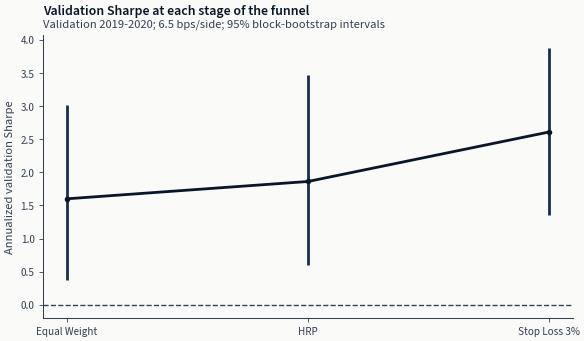

In [13]:
fig_stage, ax_stage = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
x = list(range(len(carrier)))
points = carrier["sharpe"].to_list()
lower = carrier["sharpe_ci95_lo"].to_list()
upper = carrier["sharpe_ci95_hi"].to_list()
ax_stage.errorbar(
    x,
    points,
    yerr=[
        [point - lo for point, lo in zip(points, lower, strict=True)],
        [hi - point for point, hi in zip(points, upper, strict=True)],
    ],
    marker="o",
    color=COLORS["blue"],
    ecolor=COLORS["slate"],
    capsize=4,
    linewidth=2,
)
ax_stage.axhline(0, color=COLORS["neutral"], linestyle="--", linewidth=1)


_ACRONYMS = {"mvo", "hrp", "gbm", "sdf", "sae", "ipca", "lstm"}


def as_label(name: str) -> str:
    """Registry identifier rendered for a chart axis or title."""
    words = []
    for word in name.replace("_", " ").split():
        if word.lower() in _ACRONYMS:
            words.append(word.upper())
        elif word.endswith("pct") and word[:-3].isdigit():
            words.append(f"{word[:-3]}%")
        else:
            words.append(word.capitalize())
    return " ".join(words)


ax_stage.set_xticks(x, [as_label(stage) for stage in carrier["stage"].to_list()])
ax_stage.set_ylabel("Annualized validation Sharpe")
add_message_title(
    ax_stage,
    "Validation Sharpe at each stage of the funnel",
    f"Validation 2019-2020; {CONFIGURED_COST_BPS:.1f} bps/side; 95% block-bootstrap intervals",
)
fig_stage.show()

## 2. Cost survival on the strategy the case study selected

The cost surface is measured on the carrier itself - the risk overlay included, where one was
selected - because that is the strategy `17_costs` stresses and the one this case study would
publish. Measuring it on the un-overlaid parent instead would report the friction of a
strategy nobody is proposing to trade.

Exact planned hashes keep alternate lineages and removed allocators out of the curve.

In [14]:
cost_plans = []
for cost_bps in get_cost_grid_bps(CASE_STUDY):
    spec = set_backtest_costs_bps(
        clone_backtest_spec(cost_base),
        commission_bps=cost_bps / 2,
        slippage_bps=cost_bps / 2,
    )
    spec["chapter"] = "ch18"
    cost_plans.append(
        {
            "regime": "bps",
            "cost_value": float(cost_bps),
            "backtest_hash": backtest_hash_from_parts(strategy_carrier["prediction_hash"], spec),
        }
    )

The per-share companion uses the same carrier and changes only the cost
convention.

In [15]:
for half_spread in get_cost_grid_half_spread_usd(CASE_STUDY):
    spec = set_backtest_costs_per_share(
        clone_backtest_spec(cost_base),
        per_share=get_per_share_commission(CASE_STUDY),
        default_half_spread_usd=half_spread,
    )
    spec["chapter"] = "ch18"
    cost_plans.append(
        {
            "regime": "per_share",
            "cost_value": float(half_spread),
            "backtest_hash": backtest_hash_from_parts(strategy_carrier["prediction_hash"], spec),
        }
    )

In [16]:
cost_hashes = [plan["backtest_hash"] for plan in cost_plans]
with sqlite3.connect(REGISTRY_DB) as db:
    cost_metrics = pl.read_database(
        f"""
        SELECT b.backtest_hash, b.stage, bm.sharpe,
               bm.sharpe_ci95_lo, bm.sharpe_ci95_hi
        FROM backtest_runs b
        JOIN backtest_metrics bm ON b.backtest_hash = bm.backtest_hash
        WHERE b.backtest_hash IN ({",".join("?" for _ in cost_hashes)})
        """,
        connection=db,
        execute_options={"parameters": cost_hashes},
    )
cost_metrics = cost_metrics.with_columns(pl.col("backtest_hash").cast(pl.String))
cost_surface = pl.DataFrame(cost_plans).join(cost_metrics, on="backtest_hash", how="inner")
# Same direction as the risk surface above: nothing UNPLANNED may enter, and the declared grid
# is a property of the configuration while what is registered is a property of the run.
_planned_costs = {plan["backtest_hash"] for plan in cost_plans}
with sqlite3.connect(REGISTRY_DB) as db:
    _registered_costs = {
        row[0]
        for row in db.execute(
            "SELECT backtest_hash FROM backtest_runs "
            "WHERE prediction_hash = ? AND stage = 'cost_sensitivity'",
            (strategy_carrier["prediction_hash"],),
        )
    }
_unplanned_costs = _registered_costs - _planned_costs
if _unplanned_costs:
    raise RuntimeError(
        f"{len(_unplanned_costs)} cost row(s) on carrier "
        f"{strategy_carrier['prediction_hash']} are not on the declared cost grid: "
        + ", ".join(sorted(_unplanned_costs)[:5])
    )
if cost_surface.is_empty():
    raise RuntimeError(
        f"no declared cost level is registered for carrier "
        f"{strategy_carrier['prediction_hash']}, so there is no cost surface to report"
    )
if len(cost_surface) != len(cost_plans):
    print(
        f"{len(cost_surface)} of {len(cost_plans)} declared cost levels are registered for this "
        "carrier; the surface below covers those and says nothing about the rest"
    )
if cost_surface.filter(pl.col("stage") != "cost_sensitivity").height:
    raise RuntimeError("A corrected cost hash has the wrong registry stage")

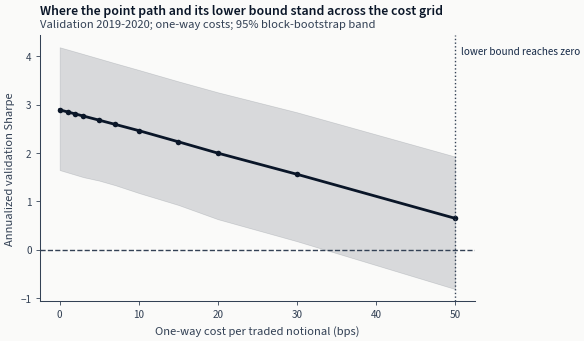

In [17]:
bps = cost_surface.filter(pl.col("regime") == "bps").sort("cost_value")


def first_zero_cost(column: str) -> float | None:
    """Lowest grid cost at which `column` reaches zero, or None if it never does."""
    reached = bps.filter(pl.col(column) <= 0)
    return reached["cost_value"].min() if reached.height else None


first_crossing = first_zero_cost("sharpe_ci95_lo")
point_crossing = first_zero_cost("sharpe")
max_bps = bps["cost_value"].max()

fig_cost, ax_cost = plt.subplots(figsize=FIGSIZE["single"], constrained_layout=True)
ax_cost.plot(
    bps["cost_value"],
    bps["sharpe"],
    marker="o",
    color=COLORS["blue"],
    linewidth=2,
)
ax_cost.fill_between(
    bps["cost_value"],
    bps["sharpe_ci95_lo"],
    bps["sharpe_ci95_hi"],
    color=COLORS["blue"],
    alpha=0.14,
)
ax_cost.axhline(0, color=COLORS["neutral"], linestyle="--", linewidth=1)
ax_cost.set_xlabel("One-way cost per traded notional (bps)")
ax_cost.set_ylabel("Annualized validation Sharpe")
if first_crossing is not None:
    ax_cost.axvline(first_crossing, color=COLORS["neutral"], linestyle=":", linewidth=1)
    ax_cost.annotate(
        "lower bound reaches zero",
        (first_crossing, ax_cost.get_ylim()[1]),
        xytext=(4, -8),
        textcoords="offset points",
        fontsize=8,
        color=COLORS["slate"],
        va="top",
    )
add_message_title(
    ax_cost,
    "Where the point path and its lower bound stand across the cost grid",
    "Validation 2019-2020; one-way costs; 95% block-bootstrap band",
)
fig_cost.show()

In [18]:
def _crossing(cost: float | None) -> str:
    return f"{cost:.0f} bps" if cost is not None else "not within the grid"


print(
    f"Lower bound first reaches zero: {_crossing(first_crossing)}; "
    f"point Sharpe first reaches zero: {_crossing(point_crossing)}; "
    f"grid runs to {max_bps:.0f} bps one-way, where point Sharpe is {bps['sharpe'][-1]:.3f}"
)

Lower bound first reaches zero: 50 bps; point Sharpe first reaches zero: not within the grid; grid runs to 50 bps one-way, where point Sharpe is 0.646


The printout above gives the cost at which each of the two first reaches zero,
or says that it does not inside the grid. The lower bound's crossing, not the
point path's, is what bounds a cost claim: a point Sharpe still above zero with
a band that straddles it is a robustness result, not an estimate of net
performance.

## 3. Paired risk effect and risk-cohort selection adjustment

The leading overlay is compared with its exact allocation baseline on aligned
timestamps. The risk-only cohort then asks how much of that apparent lead
could arise from choosing among the declared controls. It does not erase the earlier
model and allocation search, so it is a lower bound on the total search cost.

In [19]:
# The un-overlaid parent, not the carrier. On an overlaid carrier the two are different rows,
# and using the carrier here would compare the winning overlay with itself and report a paired
# difference of exactly zero.
baseline_returns = canonical_daily_returns(NO_OVERLAY_HASH)
leader_returns = canonical_daily_returns(risk_leader["backtest_hash"])
if baseline_returns is None or leader_returns is None:
    raise RuntimeError("Missing daily returns for the corrected carrier")
aligned = (
    baseline_returns.rename({"ret": "baseline_ret"})
    .join(leader_returns.rename({"ret": "challenger_ret"}), on="timestamp", how="inner")
    .sort("timestamp")
)
if aligned.is_empty():
    raise RuntimeError("The overlay and its baseline are flat across the canonical window")
# `challenger_overlays_baseline` says what a flat session on the challenger means, and here
# the challenger is a risk overlay running on top of this exact carrier. Both are live from
# the carrier's first traded session, so a session the overlay sits out is a position it
# chose to hold and belongs in the comparison - it is the effect being measured. The default
# is for two independent series, where the challenger's leading zeros are a warmup before its
# first signal, and applying it here would delete the overlay's largest effect and pull
# `sharpe_diff` toward zero in the direction the overlay is under test.
paired_risk = compute_paired_uncertainty(
    aligned["challenger_ret"],
    aligned["baseline_ret"],
    periods_per_year=PERIODS_PER_YEAR,
    case_study=CASE_STUDY,
    label=LABEL,
    n_boot=2000,
    seed=SEED,
    challenger_overlays_baseline=True,
)

Selection adjustment uses only the predeclared risk overlays and keeps
the no-overlay carrier as the economic benchmark.

In [20]:
returns_by_hash = {
    backtest_hash: canonical_daily_returns(backtest_hash)
    for backtest_hash in risk_surface["backtest_hash"]
}
fold_returns_by_hash = {
    backtest_hash: load_backtest_fold_metrics(CASE_STUDY, backtest_hash=backtest_hash)[
        "sharpe"
    ].to_numpy()
    for backtest_hash in risk_surface["backtest_hash"]
}
risk_cohort = compute_cohort_metrics(
    returns_by_hash,
    periods_per_year=PERIODS_PER_YEAR,
    baseline_returns=baseline_returns,
    fold_returns_by_hash=fold_returns_by_hash,
    rademacher_n_simulations=2000,
    rademacher_seed=SEED,
)
if (
    risk_leader["risk_type"] != "none"
    and risk_cohort.get("leader_hash") != risk_leader["backtest_hash"]
):
    raise RuntimeError("Risk cohort leader does not match the corrected carrier")

In [21]:
risk_diagnostics = pl.DataFrame(
    [
        {"diagnostic": "Paired Sharpe difference", "value": paired_risk["sharpe_diff"]},
        {"diagnostic": "Paired 95% lower bound", "value": paired_risk["sharpe_diff_ci95_lo"]},
        {"diagnostic": "Paired 95% upper bound", "value": paired_risk["sharpe_diff_ci95_hi"]},
        {"diagnostic": "Bootstrap win probability", "value": paired_risk["prob_challenger_wins"]},
        {"diagnostic": "Risk-cohort DSR ER p-value", "value": risk_cohort["dsr_er_pvalue"]},
        {"diagnostic": "Risk-cohort PBO", "value": risk_cohort["pbo"]},
        {"diagnostic": "Risk-cohort folds", "value": risk_cohort["pbo_n_folds"]},
    ]
)
print(
    f"Paired improvement of {risk_leader['risk_name']} over its allocation baseline: "
    f"{paired_risk['sharpe_diff']:+.3f} "
    f"[{paired_risk['sharpe_diff_ci95_lo']:.3f}, {paired_risk['sharpe_diff_ci95_hi']:.3f}]"
)
risk_diagnostics

Paired improvement of stop_loss_3pct over its allocation baseline: +0.751 [-0.082, 1.403]


diagnostic,value
str,f64
"""Paired Sharpe difference""",0.750922
"""Paired 95% lower bound""",-0.081799
"""Paired 95% upper bound""",1.402835
"""Bootstrap win probability""",0.9545
"""Risk-cohort DSR ER p-value""",0.000022
"""Risk-cohort PBO""",0.5
"""Risk-cohort folds""",2.0


The paired interval above is the risk rule's own effect, measured against its
exact allocation baseline on aligned timestamps. The selection-adjusted
diagnostics in the same table account for choosing among the fixed
controls, but only two validation folds remain available for temporal
stability analysis, so the cohort statistics rest on a thin sample.

## 4. Holdout result

The holdout is produced by `18_holdout_predictions` and scored by
`19_holdout_backtest`, on the configuration this funnel selected. This section reads
that result; it does not create one, and it applies no gate to it.

There is deliberately no seal here, and an earlier version of this notebook had an
elaborate one - a research lock, a four-state ordering check on when the fit ran against
when the lock was taken, a field-by-field identity diff between the sealed and published
fits, and a `holdout_evaluations` lineage read. All of it existed to make the holdout
unrepeatable and to adjudicate what to do when the carrier changed underneath it. The
holdout is repeatable: if it is run on the wrong configuration, it is run again on the
right one. Machinery whose purpose is to prevent that is machinery whose purpose is to
preserve a stale answer, so it is gone rather than parked. What replaces it is a count: the
earlier rows stay, and a window carrying more than one holdout fit is reported as one that
has been read more than once.

What remains worth checking is not whether the holdout was allowed to run, but whether the
rows on disk describe the configuration this funnel actually selected. That is one join
and it is below.

In [22]:
with sqlite3.connect(REGISTRY_DB) as db:
    carrier_training_hash = db.execute(
        "SELECT training_hash FROM prediction_sets WHERE prediction_hash = ?",
        (strategy_carrier["prediction_hash"],),
    ).fetchone()[0]
    holdout_rows = db.execute(
        """
        SELECT b.backtest_hash, p.prediction_hash, p.training_hash, t.family, t.config_name,
               b.spec_json, bm.sharpe, bm.sharpe_ci95_lo, bm.sharpe_ci95_hi, bm.max_drawdown,
               t.label, p.checkpoint_kind, p.checkpoint_value, t.spec_json AS training_spec_json
        FROM backtest_runs b
        JOIN backtest_metrics bm ON b.backtest_hash = bm.backtest_hash
        JOIN prediction_sets p ON b.prediction_hash = p.prediction_hash
        JOIN training_runs t ON p.training_hash = t.training_hash
        WHERE b.stage = 'holdout'
        ORDER BY b.created_at
        """
    ).fetchall()

The carrier's holdout fit is a *different training run* from its validation fit, always and
by construction: the cross-validation geometry is part of the training identity, and the
holdout fold is not the validation folds. So a holdout row cannot be matched to the carrier
by training hash.

Five things have to agree instead, and the model name is only one of them.

- **Family, configuration and label** say the same estimator was fitted against the same
  target, which is what [`18_holdout_predictions`](18_holdout_predictions.ipynb) refits.
- **The training specification outside the re-keyed fields** says the same computation over
  the same pinned artifacts. Names alone would accept a fit against a retired feature
  artifact, which is a different estimator wearing the same label.
- **The checkpoint** says the same point on the training schedule that selection was made at.
  A model publishing ten checkpoints would otherwise offer ten holdout results.
- **The strategy projection** - allocator, concentration, risk overlay, execution and costs -
  says the same portfolio was built from those predictions, which is what
  [`19_holdout_backtest`](19_holdout_backtest.ipynb) runs.

Matching on the model alone would accept a holdout row for this model under some other
allocator, or against a stale artifact, and report either as the carrier's own out-of-sample
result.

In [23]:
with sqlite3.connect(REGISTRY_DB) as db:
    carrier_source = db.execute(
        "SELECT family, config_name, label, spec_json FROM training_runs WHERE training_hash = ?",
        (carrier_training_hash,),
    ).fetchone()
    carrier_checkpoint = db.execute(
        "SELECT checkpoint_kind, checkpoint_value FROM prediction_sets WHERE prediction_hash = ?",
        (strategy_carrier["prediction_hash"],),
    ).fetchone()
if carrier_source is None or carrier_checkpoint is None:
    raise RuntimeError(f"the carrier lineage {carrier_training_hash} is not in this registry")


def _without(value, path: tuple[str, ...]):
    """``value`` with ``path`` removed, leaving every sibling in place."""
    if not isinstance(value, dict) or path[0] not in value:
        return value
    pruned = dict(value)
    if len(path) == 1:
        pruned.pop(path[0])
    else:
        pruned[path[0]] = _without(pruned[path[0]], path[1:])
    return pruned


# The whole backtest specification, not the strategy block. `strategy_view` returns signal,
# allocation and risk and stops there, so a comparison built on it accepts a holdout run at
# different commissions, slippage, fill timing or stop behaviour as the carrier's own result -
# and those are exactly the settings a holdout has to hold fixed for its number to be comparable.
# What legitimately differs between the two runs is the predictions it consumed and the price
# panel it was sliced to, so only those are projected out.
BACKTEST_VARYING_PATHS = (
    ("_runtime_backtest_config",),
    ("input_identity",),
    ("backtest_config", "metadata", "prediction_hash"),
    ("backtest_config", "metadata", "preset_path"),
)


def _comparable_backtest(spec: dict) -> dict:
    projected = spec
    for path in BACKTEST_VARYING_PATHS:
        projected = _without(projected, path)
    return projected


CARRIER_BACKTEST = _comparable_backtest(json.loads(strategy_carrier["spec_json"]))
CARRIER_TRAINING_SPEC = json.loads(carrier_source[3])


# The identity the carrier's configuration *should* have on the holdout, derived rather than
# approximated by comparing fields. `build_holdout_training_spec` is the same derivation
# 18_holdout_predictions fits and 19_holdout_backtest checks, so every boundary is inside the
# hash - the label buffer, the feature floor that bounds the training start, the fold identifier
# and the request metadata - and a fit differing in any of them is simply a different identity.
# It costs a dataset read rather than a fit.
OBSERVATIONS = (
    pl.read_parquet(_study.root / "labels" / f"{carrier_source[2]}.parquet")
    .get_column("timestamp")
    .unique()
    .sort()
    .to_list()
)
# The derivation needs a CURRENT resolved training specification - it re-keys the resolver's
# per-fold fields onto the holdout fold - so a carrier fitted before that schema cannot be
# matched this way. Where it can be derived it is the strongest available check and is used;
# where it cannot, the weaker structural match runs and the notebook says which one answered,
# because "this is the carrier's holdout" and "this is a holdout of the same configuration" are
# different claims and the reader is entitled to know which is being made.
try:
    EXPECTED_HOLDOUT_TRAINING = training_hash_from_spec(
        build_holdout_training_spec(
            _study, CARRIER_TRAINING_SPEC, timeline=OBSERVATIONS, case_study=CASE_STUDY
        )
    )
    HOLDOUT_MATCH_BASIS = f"derived training identity {EXPECTED_HOLDOUT_TRAINING}"
except (ValueError, KeyError, NotImplementedError) as exc:
    EXPECTED_HOLDOUT_TRAINING = None
    HOLDOUT_MATCH_BASIS = (
        f"family, configuration, label, checkpoint and strategy - the holdout identity could "
        f"not be derived from this carrier's training specification ({exc})"
    )
print(f"Holdout rows are matched to the carrier by {HOLDOUT_MATCH_BASIS}")


def is_this_carriers_holdout(row) -> bool:
    """The carrier's own configuration, refitted for the holdout, at the selected checkpoint.

    The training identity does most of the work when it can be derived: a fit over different
    dates, at a different seed, in a different tier, or against a retired feature artifact is a
    different hash and cannot match. Where it cannot be derived the same three properties are
    checked directly - same estimator against the same target, over the holdout split - which is
    weaker because it does not pin the interval.

    Either way the checkpoint must be the one selection was made at, and the backtest
    specification must describe the same portfolio, including the costs, fill timing and stop
    behaviour a strategy-block comparison would let vary.
    """
    if (row[11], row[12]) != carrier_checkpoint:
        return False
    if _comparable_backtest(json.loads(row[5])) != CARRIER_BACKTEST:
        return False
    if EXPECTED_HOLDOUT_TRAINING is not None:
        return row[2] == EXPECTED_HOLDOUT_TRAINING
    if (row[3], row[4], row[10]) != (carrier_source[0], carrier_source[1], carrier_source[2]):
        return False
    _cv = (json.loads(row[13])["computation"].get("cv") or {}) if row[13] else {}
    return _cv.get("split") == "holdout"


matching = [r for r in holdout_rows if is_this_carriers_holdout(r)]
if len(matching) > 1:
    raise RuntimeError(
        f"{len(matching)} holdout rows match this carrier: "
        + ", ".join(r[0] for r in matching)
        + ". Two holdout results for one configuration cannot both be the out-of-sample "
        "evidence for it, and this notebook will not pick between them. Both rows stay in the "
        "registry - they are the record that the window was read twice - and the case study "
        "has to say which read it is publishing and why."
    )
holdout_result = matching[-1] if matching else None

# Every holdout lineage on this label, counted from `prediction_sets` rather than from the
# backtest rows above. Two reasons, and the second is the one that bites. A lineage belonging to
# some other configuration still means the 2021 window was read, so counting only the matches
# would report a second-or-later read as clean evidence. And a fit that 18 registered but 19
# never backtested has no row in `backtest_runs` at all - the window was read to produce those
# predictions just the same, and reading the count off the backtests would miss it entirely.
with sqlite3.connect(REGISTRY_DB) as db:
    WINDOW_READS = {
        row[0]
        for row in db.execute(
            "SELECT DISTINCT p.training_hash FROM prediction_sets p "
            "JOIN training_runs t USING(training_hash) "
            "WHERE p.split = 'holdout' AND t.label = ?",
            (carrier_source[2],),
        )
    }
print(f"Carrier: {carrier_source[0]}/{carrier_source[1]} on {carrier_source[2]}")
if len(WINDOW_READS) > 1:
    print(
        f"The 2021 window carries {len(WINDOW_READS)} holdout training identities "
        f"({', '.join(sorted(WINDOW_READS))}), so it has been read on more than one "
        "configuration. Whichever of them this page reports, it is not a first read of an "
        "unseen window, and the out-of-sample claim below has to be discounted accordingly."
    )
print(f"Holdout rows in the registry: {len(holdout_rows)}; matching this carrier: {len(matching)}")
if holdout_result is None:
    print(
        "No holdout backtest for this configuration. Run 18_holdout_predictions and "
        "19_holdout_backtest. Any holdout rows already present describe a configuration the "
        "funnel no longer selects; leave them where they are, because they are the record "
        "that the window was read on that configuration."
    )
else:
    print(
        f"Holdout Sharpe {holdout_result[6]:.3f} "
        f"[{holdout_result[7]:.3f}, {holdout_result[8]:.3f}], "
        f"max drawdown {holdout_result[9]:.3f}"
    )

Holdout rows are matched to the carrier by derived training identity 20dcd7aa0224
Carrier: gbm/default_mae on fwd_ret_risk_adj_5d
Holdout rows in the registry: 1; matching this carrier: 1
Holdout Sharpe 1.317 [-0.430, 3.056], max drawdown -0.072


In [24]:
pl.DataFrame(
    [
        {
            "backtest_hash": r[0],
            "prediction_hash": r[1],
            "family": r[3],
            "config": r[4],
            "allocator": (strategy_view(json.loads(r[5])).get("allocation") or {}).get("method"),
            "risk": (strategy_view(json.loads(r[5])).get("risk") or {}).get("name"),
            "sharpe": r[6],
            "sharpe_ci_lo": r[7],
            "sharpe_ci_hi": r[8],
            "max_drawdown": r[9],
            "matches_carrier": is_this_carriers_holdout(r),
        }
        for r in holdout_rows
    ]
    if holdout_rows
    else []
)

backtest_hash,prediction_hash,family,config,allocator,risk,sharpe,sharpe_ci_lo,sharpe_ci_hi,max_drawdown,matches_carrier
str,str,str,str,str,str,f64,f64,f64,f64,bool
"""4669b810fc64""","""79c65b6dda2f""","""gbm""","""default_mae""","""hrp""","""stop_loss_3pct""",1.316705,-0.429554,3.055807,-0.072219,true


The holdout number is one draw on one window, and its interval says how little that pins
down. It is reported beside the validation result rather than in place of it: a validation
Sharpe is the average of several folds and a holdout Sharpe is a single period, so the two
are not the same measurement and the holdout being lower or higher is not by itself
evidence that validation was optimistic. What it does establish is that the configuration
the funnel selected was run once on data no stage of the selection saw.

## 5. Publication assessment

The corrected validation record is internally closed: every planned
allocation, cost, and risk hash exists and the selected risk result
reproduces exactly. Closed is not the same as favorable. The gate table below
reports each check on its own terms, and the paired risk interval is the one
to read carefully. The remaining gap is not a computation failure and not a
missing holdout: it is that the holdout was spent on a fit whose training
identity this case study has since replaced.

In [25]:
final_row = carrier.row(len(carrier) - 1, named=True)
stress = bps.sort("cost_value").row(len(bps) - 1, named=True)
assessment = pl.DataFrame(
    [
        {
            "gate": "Corrected validation carrier",
            "status": "PASS",
            "evidence": (
                f"{carrier_family}/{carrier_config} / {strategy_carrier['allocator']} / "
                f"top {strategy_carrier['top_k']} / {risk_leader['risk_name']}"
            ),
        },
        {
            "gate": "Validation Sharpe uncertainty",
            "status": "PASS" if final_row["sharpe_ci95_lo"] > 0 else "INCONCLUSIVE",
            "evidence": (
                f"{final_row['sharpe']:.3f} "
                f"[{final_row['sharpe_ci95_lo']:.3f}, {final_row['sharpe_ci95_hi']:.3f}]"
            ),
        },
        {
            "gate": "Paired risk improvement",
            "status": "PASS" if paired_risk["sharpe_diff_ci95_lo"] > 0 else "INCONCLUSIVE",
            "evidence": (
                f"{paired_risk['sharpe_diff']:+.3f} "
                f"[{paired_risk['sharpe_diff_ci95_lo']:.3f}, "
                f"{paired_risk['sharpe_diff_ci95_hi']:.3f}]"
            ),
        },
        {
            "gate": f"{stress['cost_value']:.0f} bps point stress",
            "status": "PASS" if stress["sharpe"] > 0 else "FAIL",
            "evidence": (
                f"Sharpe {stress['sharpe']:.3f} "
                f"[{stress['sharpe_ci95_lo']:.3f}, {stress['sharpe_ci95_hi']:.3f}]"
            ),
        },
        {
            # Not a gate on whether the holdout was permitted to run - it is repeatable and
            # nothing here polices that. Two questions instead: is there a holdout result for
            # the configuration this funnel selected, and had the window already been read?
            # A result whose lower bound clears zero still cannot PASS on a window that was
            # read before, because a second read of a seen window is not out of sample
            # whatever number it produces.
            "gate": "Holdout on the selected configuration",
            "status": (
                "NOT RUN"
                if holdout_result is None
                else "INCONCLUSIVE"
                if len(WINDOW_READS) > 1 or holdout_result[7] <= 0
                else "PASS"
            ),
            "evidence": (
                "no holdout backtest for this configuration"
                if holdout_result is None
                else (
                    f"{holdout_result[6]:.3f} [{holdout_result[7]:.3f}, {holdout_result[8]:.3f}]"
                    + (
                        f"; window read on {len(WINDOW_READS)} configurations, so not a first read"
                        if len(WINDOW_READS) > 1
                        else ""
                    )
                )
            ),
        },
        {
            "gate": "Deployment claim",
            "status": "FAIL",
            "evidence": "validation-positive is not out-of-sample efficacy",
        },
    ]
)
assessment

gate,status,evidence
str,str,str
"""Corrected validation carrier""","""PASS""","""gbm/default_mae / hrp / top 5 …"
"""Validation Sharpe uncertainty""","""PASS""","""2.609 [1.357, 3.877]"""
"""Paired risk improvement""","""INCONCLUSIVE""","""+0.751 [-0.082, 1.403]"""
"""50 bps point stress""","""PASS""","""Sharpe 0.646 [-0.817, 1.924]"""
"""Holdout on the selected config…","""INCONCLUSIVE""","""1.317 [-0.430, 3.056]"""
"""Deployment claim""","""FAIL""","""validation-positive is not out…"


## Key takeaways

1. The corrected v3.1 validation carrier is the model, allocator, top-k, and
   risk rule named in the assessment table above. Eligibility is decided by
   coverage of the canonical validation window, so a checkpoint whose extra
   decision dates fall outside that window earns no advantage.
2. The stage chart shows Sharpe at each stage the funnel actually produced,
   which is between one and three points depending on whether allocation and
   the risk rule each improved on what came before. The interval at every
   stage is wide: the point path moves far more than the uncertainty around it
   narrows.
3. The risk rule's paired improvement is reported with its own interval
   against the exact allocation baseline. Selection adjustment covers the fixed
   controls, but only two validation folds remain for stability analysis.
4. The cost curve is read from its lower bound, not its point path. The cell
   under the cost chart reports where each first reaches zero, and the lower
   bound's crossing is the one a cost claim has to respect.
5. The holdout is read, not gated. Section 4 reports the 2021 result for the
   configuration this funnel selected, with its interval, beside the
   validation record rather than in place of it: a validation Sharpe averages
   several folds and a holdout Sharpe is one period, so the two are different
   measurements and a gap between them is not by itself evidence that
   validation was optimistic. If the holdout rows ever describe a
   configuration the funnel no longer selects, the two holdout notebooks are
   re-run on the one it does - nothing here prevents that, and nothing should.
   The superseded rows stay: they are the only record that the window was read
   before, and this page counts them and says so.
6. What the record supports is a validation result on a stated configuration
   plus one out-of-sample draw on it. One draw with a wide interval is not a
   deployment claim, and this notebook makes none.